# **Implementazione del sampling e della stima del valore d'aspettazione**

In [1]:
#!pip install qiskit qiskit-ibm-runtime qiskit-aer numpy matplotlib pylatexenc

In [2]:
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeTorino
backend_aer = AerSimulator()
backend_torino = FakeTorino()

In [3]:
from qiskit_ibm_runtime.executor_sampler import Sampler

sampler_aer = Sampler(mode=backend_aer)
sampler_torino = Sampler(mode=backend_torino)

## Creare circuiti parametrici

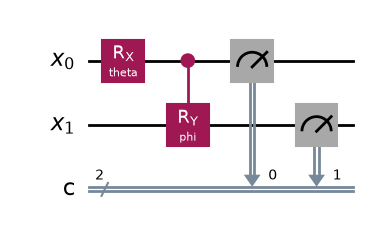

In [4]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit import Parameter

qx = QuantumRegister(2, 'x')
cx = ClassicalRegister(2, 'c')
theta = Parameter('theta')
phi = Parameter('phi')

qc = QuantumCircuit(qx, cx)
qc.rx(theta, 0)
qc.cry(phi, 0, 1)
qc.measure(qx, cx)
qc.draw('mpl')

In [5]:
# con qc.parameters possiamo accedere ad una lista dei parametri del circuito
print(qc.parameters)

ParameterView([Parameter(phi), Parameter(theta)])


In [6]:
from math import pi
# costruiamo una lista di liste di parametri

params = [[pi/2, pi/4], [pi/3, pi/6]]

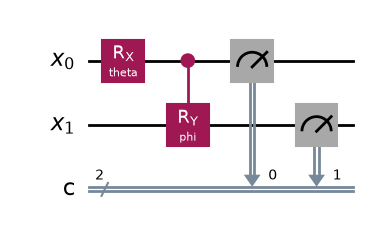

In [7]:
from qiskit import transpile

qc_aer_transp = transpile(qc, backend_aer)
qc_aer_transp.draw('mpl')

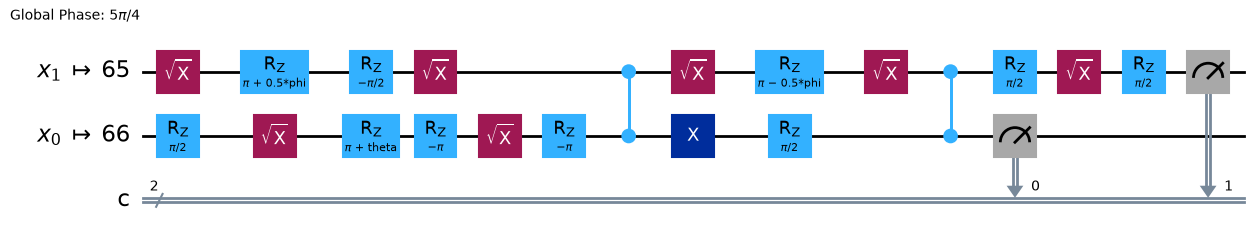

In [8]:
qc_torino_transp = transpile(qc, backend_torino)
qc_torino_transp.draw('mpl')

In [9]:
job_aer = sampler_aer.run([(qc_aer_transp, params, 1000)])
# gli argomenti sono: [(circuito transpilato, parametri, shots)_1, ([*config*])_2...]
result_aer = job_aer.result()
aer_counts = result_aer[0].data.c.get_counts(1) 
# l'indice dell'array indica la configurazione usata,
# l'indice del metodo indica quale dei parametri usare per quella particolare configurazione.
# se non ci sono parametri, usare "0". odio questa sintassi wtf


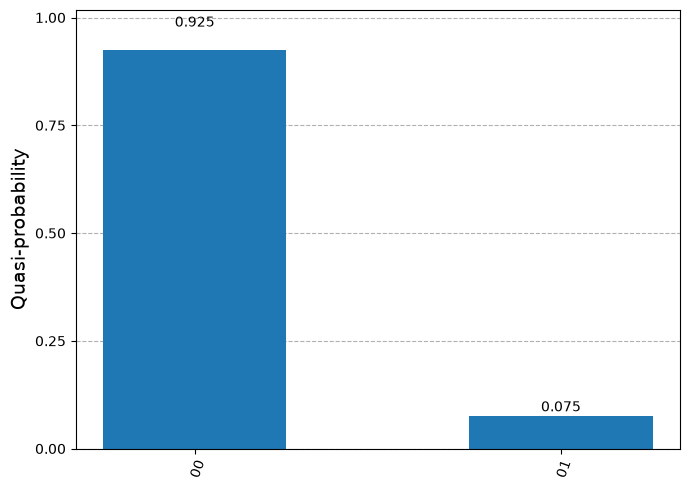

In [10]:
from qiskit.visualization import plot_distribution

plot_distribution(aer_counts)

## Approssimare valori d'aspettazione di alcune osservabili

In [11]:
# dichiariamo una lista di osservabili
from qiskit.quantum_info import SparsePauliOp
obsv_list = [[SparsePauliOp(["ZZ"], [1])], [SparsePauliOp(["XX"], [1])]]

In [12]:
torino_layout = qc_torino_transp.layout
torino_obsv = [[obsv_list[0][0].apply_layout(layout)], [obsv_list[1][0].apply_layout(layout)]]

NameError: name 'layout' is not defined

In [ ]:
from qiskit_ibm_runtime.executor_estimator import Estimator
estimator_aer = Estimator(mode=backend_aer)
estimator_torino = Estimator(mode=backend_torino)

In [ ]:
job2_aer = estimator_aer.run([(qc_aer_transp, obsv_list, params, 0.01)])

exp_val_aer = job2_aer.result()[0].data.evs
print(exp_val_aer)

[[ 0.69888179  0.8688099 ]
 [-0.00339457  0.00359425]]


## Simulazioni statevector

In [ ]:
from qiskit.primitives import StatevectorEstimator, StatevectorSampler 

SVsampler = StatevectorSampler()
SVestimator = StatevectorEstimator()

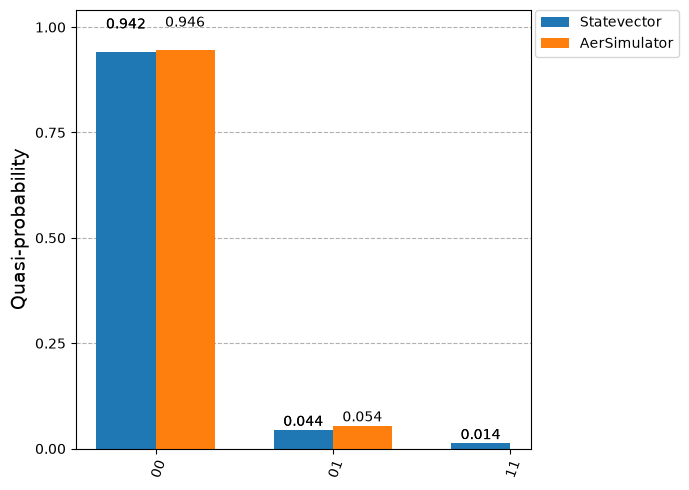

In [ ]:
job_svs = SVsampler.run([(qc,params,1000)])
results_svs = job_svs.result()
counts_svs = results_svs[0].data.c.get_counts(1)
plot_distribution([counts_svs, aer_counts], legend=["Statevector", "AerSimulator"])

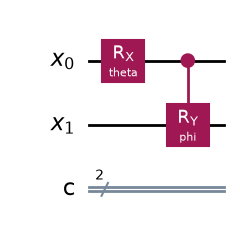

In [ ]:
qx = QuantumRegister(2, 'x')
theta = Parameter('theta')
phi = Parameter('phi')

qc2 = QuantumCircuit(qx, cx)
qc2.rx(theta, 0)
qc2.cry(phi, 0, 1)
qc2.draw('mpl')

In [ ]:
job_sve = SVestimator.run([(qc2, obsv_list, params, 0.005)])
results_sve = job_sve.result()
exp_val_sve = results_sve[0].data.evs

exp_val_sve

array([[0.8503187 , 0.9061151 ],
       [0.00364969, 0.00731143]])